In [11]:
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
with open('results/dolly_llama_nar_exp.json', 'r') as f:
    data = json.load(f)

In [5]:
print(type(data))
print(len(data))
print(data[0])

<class 'list'>
2000
{'texts': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.', 'instructions': 'When did Virgin Australia start operating?', 'categories': 'closed_qa', 'accuracy': 1.0, 'last_iter': 285, 'best_vectors': [[1.421875, 1.21875, -0.76171875, 1.078125, -0.84375, 1.6171875, -1.1484375, 0.1337890625, -0.166015625, -0.486328125, -1.578125, -2.0, 0.73046875, -0.81640625, -1.4609375, 0.7890625, -0.5234375, 1.8515625, 1.359375, 1.3515625, 0.40625, -0.7890625, 0.369140625, 1.734375, -1.1484375, -0.58203125, 0.5078125, -0.369140625, -0.3359375, -1.7421875, -0.94921875, -3.328125, 2.5625, -0.1611328125, -0.94921875, -0.369140625, -1.953125, 0.73828125, 1.109375, -0.765625, -0.9453125, 1.859375, 0.2080078125, -1.328125, 0.51171875, -1.296875, 0.302734375, -0.16015625, -1.0390625, -0.2734375, -0.408203125, 0.0015716552734375, 1.34375, 0.6953125, 1.3203125, -0.4921875, 0.00421142578125, -1.7421875, 0.69140625, -2.078125, 2.7343

In [6]:
e_vectors = []
m_vectors = []
for item in data:
    e_vectors.append(item['best_vectors'][0])
    m_vectors.append(item['best_vectors'][1])

100%|██████████| 99/99 [05:03<00:00,  3.07s/it]


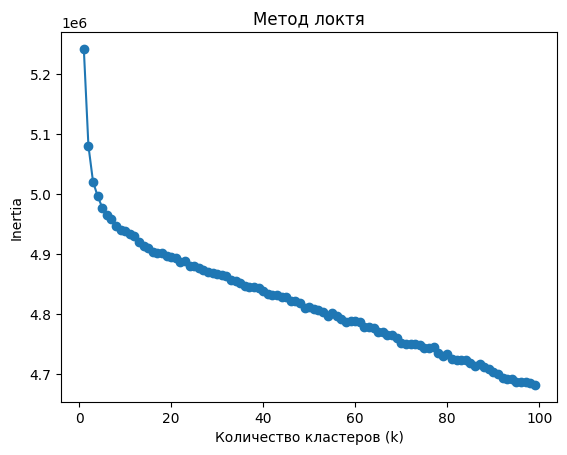

In [ ]:
inertia = []
k_values = range(1, 100)

for k in tqdm(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(e_vectors)
    inertia.append(kmeans.inertia_)

# график
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя (e token)')
plt.show()

100%|██████████| 99/99 [05:13<00:00,  3.17s/it]


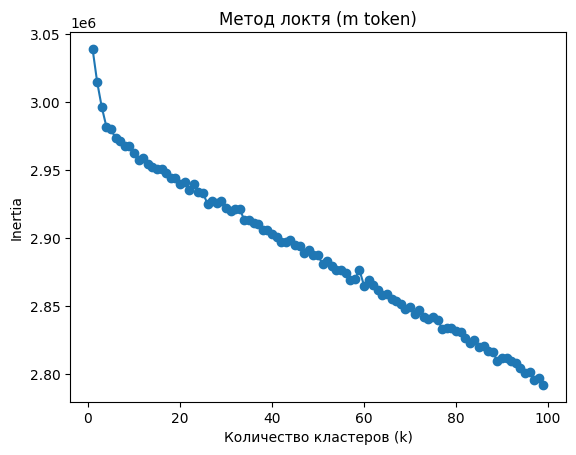

In [13]:
inertia = []
k_values = range(1, 100)

for k in tqdm(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(m_vectors)
    inertia.append(kmeans.inertia_)

# график
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя (m token)')
plt.show()